In [35]:
import pandas as pd

def clean_amazon():
    """
    Cleans 'Amazon Sale Report.csv' and adds a standardized 'style_id' column.
    """
    df = pd.read_csv('/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/Amazon Sale Report.csv', index_col='index', low_memory=False)
    
    columns_to_drop = ['Unnamed: 22', 'fulfilled-by', 'Order ID', 'ASIN']
    df.drop(columns=columns_to_drop, inplace=True)
    
    df['Amount'] = df['Amount'].fillna(0)
    df['Courier Status'].fillna('Unknown', inplace=True)
    df['promotion-ids'].fillna('No Promotion', inplace=True)
    df.dropna(subset=['ship-city', 'ship-state', 'ship-postal-code', 'currency'], inplace=True)
    
    df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y', errors='coerce')
    df['ship-postal-code'] = df['ship-postal-code'].astype(int)
    
    # Create the standardized style_id column
    df['style_id'] = df['Style']
    
    df = df[df['Qty'] > 0].copy()
    return df

Why Was 10% of the Data Removed?
The vast majority of those removed rows were records where the Qty (quantity) sold was 0.

Here’s why removing them is crucial for our goal:

They Don't Represent Sales: A transaction with Qty of 0 is typically a cancelled order. For a demand forecasting model, we need to learn from successful sales to predict future sales. A cancelled order isn't a sale; it's the absence of one.

Focusing on the Right Signal: Our goal is to build a model that answers: "If we set the price to X, how many units will we sell?" Including cancelled orders would introduce significant noise. It would teach the model that even with a good price, a common outcome is selling nothing, which isn't the pattern we want to learn.

Improving Model Accuracy: By removing these non-sale events, we are left with a cleaner, more accurate dataset that reflects genuine consumer purchasing behavior. The model will learn the relationships between price, product features, and actual sales, leading to much better predictions.

In [36]:
import pandas as pd

def clean_international():
    """
    Cleans 'International sale Report.csv' and adds a standardized 'style_id' column.
    """
    df_intl = pd.read_csv('/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/International sale Report.csv', index_col='index')
    
    df_intl.dropna(subset=['SKU', 'PCS', 'RATE', 'GROSS AMT', 'Style'], inplace=True)
    
    numeric_cols = ['PCS', 'RATE', 'GROSS AMT']
    for col in numeric_cols:
        df_intl[col] = pd.to_numeric(df_intl[col], errors='coerce')
    df_intl.dropna(subset=numeric_cols, inplace=True)
    
    df_intl['DATE'] = pd.to_datetime(df_intl['DATE'], errors='coerce')
    df_intl.dropna(subset=['DATE'], inplace=True)
    
    rename_map = {
        'DATE': 'Date', 
        'PCS': 'Qty', 
        'GROSS AMT': 'Amount', 
        'SKU': 'SKU',
        'Style': 'style_id'  # Standardize the Style column name
    }
    df_intl.rename(columns=rename_map, inplace=True)
    
    # Keep only the relevant, renamed columns
    df_intl = df_intl[list(rename_map.values())].copy()
    
    df_intl['Qty'] = df_intl['Qty'].astype(int)
    df_intl = df_intl[df_intl['Qty'] > 0].copy()
    
    return df_intl

Why Was Over Half the Data Removed?
Missing Product Information (~2,500 rows removed):
A small initial batch of rows was removed because they were missing a SKU. A sales record without a product identifier is impossible to use, as we can't tell what was sold.

Corrupted Sales Data (~17,700 rows removed):
This was the main reason for the large drop. The columns for PCS (quantity), RATE (price), and GROSS AMT (total amount) should only contain numbers. However, in this file, thousands of rows contained non-numeric text, placeholders, or were simply blank in these crucial columns.

What this means: Imagine a row where the PCS column had the text "See notes" instead of a number like "2". This record is fundamentally corrupt; it doesn't contain a valid sale quantity.

How it was handled: My cleaning process attempts to convert these columns into a numeric format. When it encounters a value it cannot convert (like "See notes"), it flags that row as invalid. We must remove these invalid rows because they are unusable for training a model.



In [37]:
import pandas as pd

def clean_catalogs():
    """
    Cleans and combines the two product catalog files, creating a 'style_id' column.
    """
    df_pl = pd.read_csv('/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/P  L March 2021.csv', index_col='index')
    df_may = pd.read_csv('/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/May-2022.csv', index_col='index')

    def clean_and_timestamp(df, date_str):
        mrp_cols = [col for col in df.columns if 'MRP' in col]
        # Ensure 'Style Id' is included if it exists
        relevant_cols = ['Sku', 'Style Id'] + mrp_cols
        
        # Filter for columns that actually exist in the dataframe
        relevant_cols = [col for col in relevant_cols if col in df.columns]
        
        df_cleaned = df[relevant_cols].copy()
        df_cleaned.rename(columns={'Sku': 'SKU', 'Style Id': 'style_id'}, inplace=True)
        
        for col in mrp_cols:
            if col in df_cleaned.columns:
                df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
            
        df_cleaned['catalog_date'] = pd.to_datetime(date_str)
        return df_cleaned

    df_pl_cleaned = clean_and_timestamp(df_pl, '2021-03-31')
    df_may_cleaned = clean_and_timestamp(df_may, '2022-05-31')

    df_catalog_final = pd.concat([df_pl_cleaned, df_may_cleaned], ignore_index=True)
    
    mrp_cols_final = [col for col in df_catalog_final.columns if 'MRP' in col]
    df_catalog_final.dropna(subset=mrp_cols_final, how='all', inplace=True)
    df_catalog_final.dropna(subset=['style_id'], inplace=True) # Ensure style_id is not null
    
    return df_catalog_final

Summary of Cleaning Actions:
Standardized and Filtered: I extracted only the essential columns (SKU and all platform MRPs), standardized the SKU column name, and converted all pricing data into a numeric format.

Combined Files: Both the March 2021 and May 2022 catalogs have been merged into a single, comprehensive pricing master file.

Timestamped Data: Crucially, I added a catalog_date to each entry. This allows us to know which set of prices was active at a given time, which is vital for accurately modeling the effect of price on sales.

In [38]:
import pandas as pd

def clean_inventory():
    """
    Cleans 'Sale Report.csv' to get inventory levels, creating a 'style_id' column from 'Design No.'.
    """
    df_inventory = pd.read_csv('/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/Sale Report.csv', index_col='index')
    
    df_inventory.rename(columns={'SKU Code': 'SKU', 'Design No.': 'style_id'}, inplace=True)
    
    # Drop rows where the identifiers or stock are missing
    df_inventory.dropna(subset=['SKU', 'style_id', 'Stock'], inplace=True)
    
    df_inventory['Stock'] = df_inventory['Stock'].astype(int)
    
    # We only need the identifiers and the stock
    df_inventory_final = df_inventory[['SKU', 'style_id', 'Stock']].copy()
    
    # Group by both identifiers to ensure uniqueness and sum the stock
    df_inventory_final = df_inventory_final.groupby(['SKU', 'style_id'])['Stock'].sum().reset_index()
    
    return df_inventory_final

In [40]:
# --- Execute the Simplified Pipeline ---
print("Starting the simplified data preparation pipeline...")

df_amazon_clean = clean_amazon()
df_intl_clean = clean_international()
df_inventory_final = clean_inventory()
print("✅ Files have been cleaned.")

df_sales_unified = pd.concat(
    [df_amazon_clean, df_intl_clean], 
    ignore_index=True, 
    sort=False
)
print("✅ Sales data has been unified.")

# Merge the inventory data using the common 'SKU' key
df_final = pd.merge(df_sales_unified, df_inventory_final, on='SKU', how='left')
df_final['Stock'].fillna(0, inplace=True)
df_final['Stock'] = df_final['Stock'].astype(int)
print("✅ Inventory data has been merged.")

df_final.to_csv('/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/final_demand_forecasting_dataset.csv', index=False)
print("\n-----------------------------------------")
print("✅ Data preparation complete!")
print("Final dataset saved to 'final_demand_forecasting_dataset.csv'")
print("-----------------------------------------")

print(df_final.info())

Starting the simplified data preparation pipeline...


/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/1552153400.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Courier Status'].fillna('Unknown', inplace=True)
/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/1552153400.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

✅ Files have been cleaned.
✅ Sales data has been unified.
✅ Inventory data has been merged.


/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/4270057513.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['Stock'].fillna(0, inplace=True)



-----------------------------------------
✅ Data preparation complete!
Final dataset saved to 'final_demand_forecasting_dataset.csv'
-----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133254 entries, 0 to 133253
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                133254 non-null  datetime64[ns]
 1   Status              116016 non-null  object        
 2   Fulfilment          116016 non-null  object        
 3   Sales Channel       116016 non-null  object        
 4   ship-service-level  116016 non-null  object        
 5   Style               116016 non-null  object        
 6   SKU                 133254 non-null  object        
 7   Category            116016 non-null  object        
 8   Size                116016 non-null  object        
 9   Courier Status      116016 non-null  object        
 10  Qty                 1332

In [41]:
import pandas as pd

# Use the full path to your newly created master dataset
file_path = '/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/final_demand_forecasting_dataset.csv'

# Load the dataset
df = pd.read_csv(file_path)

# --- 1. Clean up duplicate style_id columns ---
# This is a normal result of merging. We'll keep the main one and drop the extra.
if 'style_id_y' in df.columns:
    df.rename(columns={'style_id_x': 'style_id'}, inplace=True)
    df.drop(columns=['style_id_y'], inplace=True)

# --- 2. Create Time-Based Features ---
# This helps the model understand weekly, monthly, and seasonal patterns.
df['Date'] = pd.to_datetime(df['Date'])
df['day_of_week'] = df['Date'].dt.dayofweek  # Monday=0, Sunday=6
df['month'] = df['Date'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)  # 1 for weekend, 0 for weekday

# --- 3. Create Product-Based Features ---
# Extracting the core product type from the SKU can help the model group similar items.
# Example: 'SET389-KR-NP-S' -> 'SET'
df['product_type'] = df['SKU'].str.split('-').str[0]

# --- 4. Save the Enriched Dataset ---
# It's good practice to save the dataset with the new features.
df.to_csv('/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/final_dataset_with_features.csv', index=False)


# --- Display the results ---
print("✅ Feature engineering complete!")
print("New columns have been added and the result is saved to 'final_dataset_with_features.csv'")

# Show the new columns in action
print("\n--- DataFrame with New Features ---")
print(df[['Date', 'day_of_week', 'is_weekend', 'SKU', 'product_type', 'Stock']].head())

/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/4021509029.py:7: DtypeWarning: Columns (1,2,3,4,5,7,8,9,11,13,14,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


✅ Feature engineering complete!
New columns have been added and the result is saved to 'final_dataset_with_features.csv'

--- DataFrame with New Features ---
        Date  day_of_week  is_weekend              SKU product_type  Stock
0 2022-04-30            5           1  JNE3781-KR-XXXL      JNE3781     96
1 2022-04-30            5           1    JNE3371-KR-XL      JNE3371      4
2 2022-04-30            5           1  JNE3671-TU-XXXL      JNE3671      6
3 2022-04-30            5           1  SET264-KR-NP-XL       SET264     81
4 2022-04-30            5           1      J0095-SET-L        J0095      1


In [42]:
import pandas as pd

# Define the file path to your dataset
# Make sure this path is correct for your local machine
file_path = '/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/final_demand_forecasting_dataset.csv'

try:
    # Load the dataset
    df = pd.read_csv(file_path)

    # --- Apply Feature Engineering ---
    if 'style_id_y' in df.columns:
        df.rename(columns={'style_id_x': 'style_id'}, inplace=True)
        df.drop(columns=['style_id_y'], inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['product_type'] = df['SKU'].str.split('-').str[0]
    
    # --- 1. Basic DataFrame Info ---
    print("--- 1. Basic DataFrame Info ---")
    print("This shows the columns, data types, and any missing data.")
    print(df.info())

    # --- 2. Descriptive Statistics for Numerical Columns ---
    print("\n\n--- 2. Descriptive Statistics for Numerical Columns ---")
    print("This summarizes metrics like average quantity, price, and stock levels.")
    print(df[['Qty', 'Amount', 'Stock']].describe())

    # --- 3. Value Counts for Key Categorical Columns ---
    print("\n\n--- 3. Value Counts for Key Categorical Columns ---")
    print("This shows the most popular items and categories.")
    
    print("\nTop 10 Product Categories:")
    print(df['Category'].value_counts().nlargest(10))
    
    print("\nTop 10 Product Sizes:")
    print(df['Size'].value_counts().nlargest(10))
    
    print("\nTop 10 Product Types (from SKU):")
    print(df['product_type'].value_counts().nlargest(10))
    
    print("\nSales Channel Distribution:")
    print(df['Channel'].value_counts())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please double-check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/3276858596.py:9: DtypeWarning: Columns (1,2,3,4,5,7,8,9,11,13,14,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


--- 1. Basic DataFrame Info ---
This shows the columns, data types, and any missing data.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133254 entries, 0 to 133253
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                133254 non-null  datetime64[ns]
 1   Status              116016 non-null  object        
 2   Fulfilment          116016 non-null  object        
 3   Sales Channel       116016 non-null  object        
 4   ship-service-level  116016 non-null  object        
 5   Style               116016 non-null  object        
 6   SKU                 133254 non-null  object        
 7   Category            116016 non-null  object        
 8   Size                116016 non-null  object        
 9   Courier Status      116016 non-null  object        
 10  Qty                 133254 non-null  int64         
 11  currency            116016 non-null  object        
 

/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/997442947.py:9: DtypeWarning: Columns (1,2,3,4,5,7,8,9,11,13,14,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


--- 1. Sales Trend Over Time ---

Data Table: Daily Sales Quantity
        Date  Qty
0 2021-06-05   20
1 2021-06-08   54
2 2021-06-11   64
3 2021-06-15   28
4 2021-06-17   21


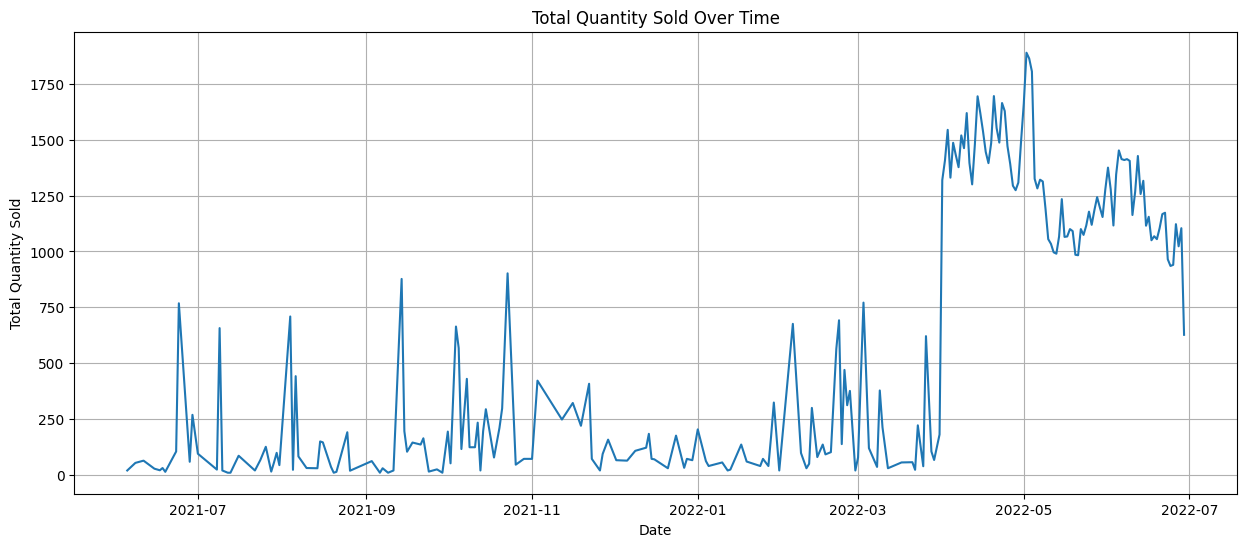



--- 2. Sales by Day of the Week ---

Data Table: Total Sales Quantity by Day
    day_name    Qty
0     Monday  19938
1    Tuesday  21127
2  Wednesday  19942
3   Thursday  19087
4     Friday  19653
5   Saturday  21178
6     Sunday  17947


/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/997442947.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_day, x='day_name', y='Qty', palette='viridis', order=sales_by_day['day_name'])


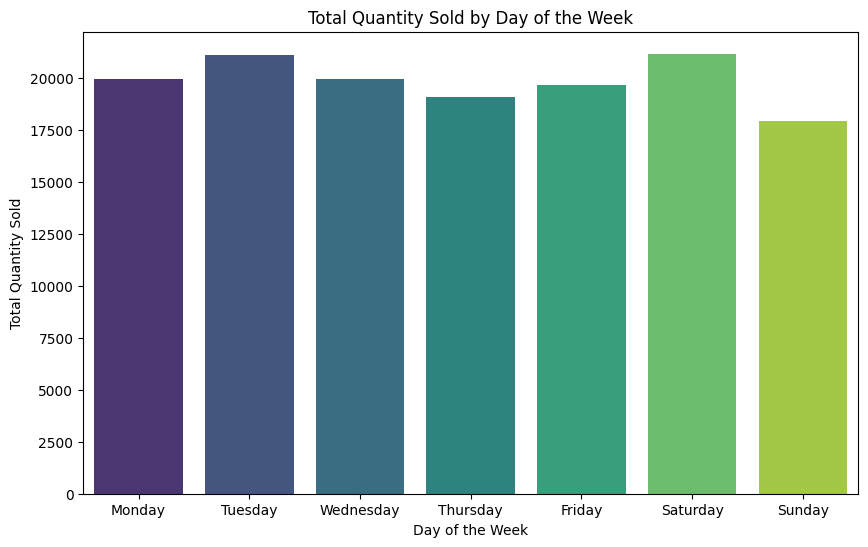



--- 3. Distribution of Transaction Amounts ---

Data Table: Distribution of Transaction Amounts in Bins
             Amount  count
0     (-2.0, 200.0]   2346
1    (200.0, 400.0]  22102
2    (400.0, 600.0]  40981
3    (600.0, 800.0]  35308
4   (800.0, 1000.0]  15675
5  (1000.0, 1200.0]   9331
6  (1200.0, 1400.0]   4150
7  (1400.0, 1600.0]   1887
8  (1600.0, 1800.0]    552
9  (1800.0, 2000.0]    172


/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/997442947.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  amount_distribution = filtered_amount.groupby(bins)['Amount'].count().reset_index(name='count')


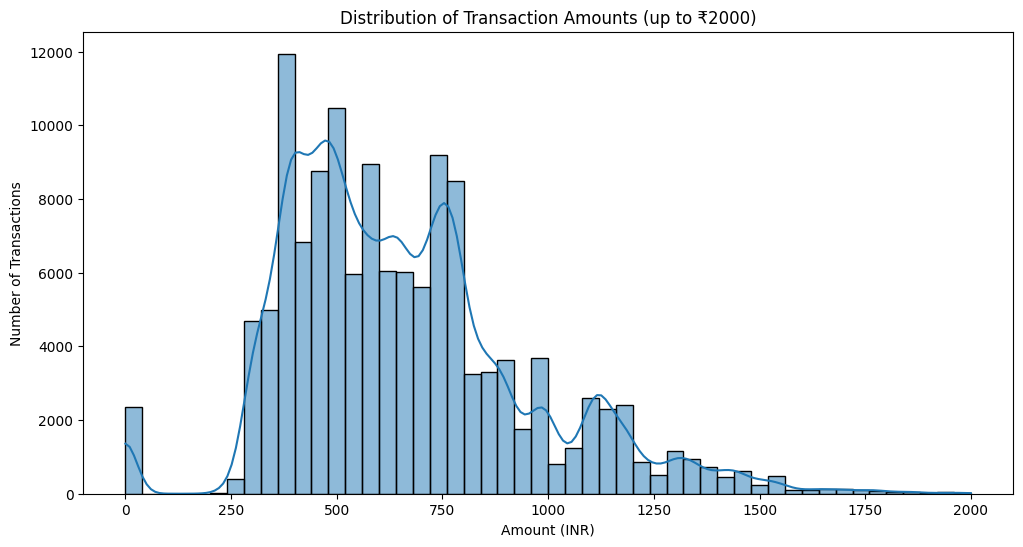

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the file path to your dataset
file_path = '/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/final_demand_forecasting_dataset.csv'

try:
    df = pd.read_csv(file_path)

    # --- Apply Feature Engineering ---
    df['Date'] = pd.to_datetime(df['Date'])
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['day_name'] = df['Date'].dt.day_name() # Get day names for easier reading

    # --- 1. Sales Trend Over Time ---
    print("--- 1. Sales Trend Over Time ---")
    sales_over_time = df.groupby('Date')['Qty'].sum().reset_index()

    print("\nData Table: Daily Sales Quantity")
    print(sales_over_time.head())

    # Create the plot
    plt.figure(figsize=(15, 6))
    sns.lineplot(data=sales_over_time, x='Date', y='Qty')
    plt.title('Total Quantity Sold Over Time')
    plt.xlabel('Date')
    plt.ylabel('Total Quantity Sold')
    plt.grid(True)
    plt.show()

    # --- 2. Sales by Day of the Week ---
    print("\n\n--- 2. Sales by Day of the Week ---")
    sales_by_day = df.groupby('day_name')['Qty'].sum().reindex(
        ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    ).reset_index()

    print("\nData Table: Total Sales Quantity by Day")
    print(sales_by_day)

    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=sales_by_day, x='day_name', y='Qty', palette='viridis', order=sales_by_day['day_name'])
    plt.title('Total Quantity Sold by Day of the Week')
    plt.xlabel('Day of the Week')
    plt.ylabel('Total Quantity Sold')
    plt.show()

    # --- 3. Distribution of Transaction Amounts ---
    print("\n\n--- 3. Distribution of Transaction Amounts ---")
    # We'll filter out the highest amounts for a clearer histogram
    filtered_amount = df[df['Amount'] <= 2000]

    # Create bins for the data table
    bins = pd.cut(filtered_amount['Amount'], bins=10)
    amount_distribution = filtered_amount.groupby(bins)['Amount'].count().reset_index(name='count')

    print("\nData Table: Distribution of Transaction Amounts in Bins")
    print(amount_distribution)

    # Create the plot
    plt.figure(figsize=(12, 6))
    sns.histplot(filtered_amount['Amount'], bins=50, kde=True)
    plt.title('Distribution of Transaction Amounts (up to ₹2000)')
    plt.xlabel('Amount (INR)')
    plt.ylabel('Number of Transactions')
    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please double-check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Finding 1: Your Sales Week Has Clear Peaks 📈
The "Sales by Day of the Week" table shows a distinct weekly pattern.

Peak Days: Saturday and Tuesday are your strongest days for sales, both with over 21,000 units sold. This suggests customers are most active on the weekend and possibly early in the week.

Weakest Day: Sunday is your slowest day.

Business Implication: You could boost sales by running targeted promotions on Sundays. For your peak days of Saturday and Tuesday, you'll want to ensure your inventory is well-stocked and your marketing is active.

Finding 2: The "Sweet Spot" for Pricing is ₹400-₹800 🎯
The "Distribution of Transaction Amounts" table is very revealing.

Core Price Range: The vast majority of your transactions—over 76,000 of them—fall into the ₹400 to ₹800 price range. This is the clear "sweet spot" for your products.

Sales Drop-off: You can see a significant drop in the number of transactions for items priced above ₹1,000.

Business Implication: This confirms the price range of your most popular, everyday items. Your demand forecasting model must be especially accurate in this range, as it represents the core of your business revenue.

/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/2976327039.py:9: DtypeWarning: Columns (1,2,3,4,5,7,8,9,11,13,14,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


--- 1. Correlation Matrix ---

Data Table: Correlation Matrix
                  Qty    Amount     Stock  day_of_week     month
Qty          1.000000  0.489592 -0.012418     0.012878  0.109177
Amount       0.489592  1.000000 -0.083714    -0.008126  0.115596
Stock       -0.012418 -0.083714  1.000000     0.000235 -0.091167
day_of_week  0.012878 -0.008126  0.000235     1.000000 -0.093981
month        0.109177  0.115596 -0.091167    -0.093981  1.000000


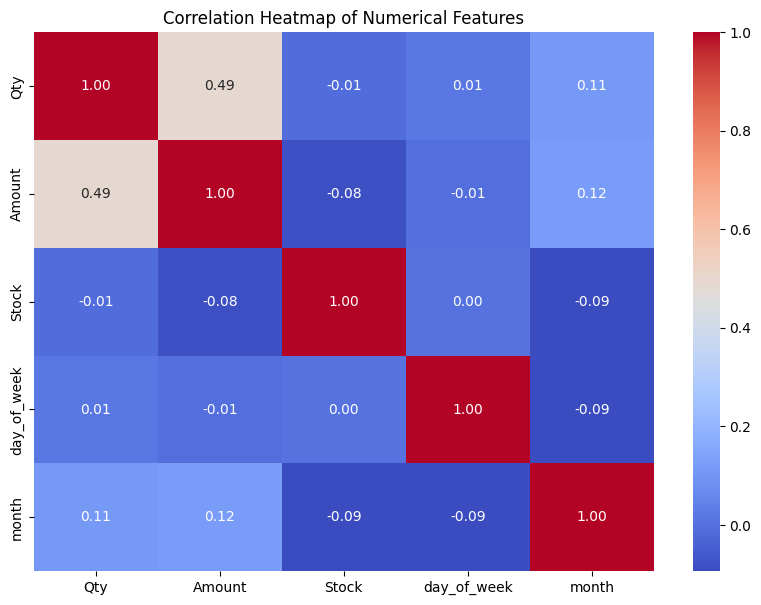



--- 2. Top Selling Categories on Saturday ---

Data Table: Top 5 Categories Sold on Saturday
        Category   Qty
0            Set  6536
1          kurta  6419
2  Western Dress  2050
3            Top  1428
4   Ethnic Dress   145


/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/2976327039.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_saturday_cats.head(5), x='Category', y='Qty', palette='magma')


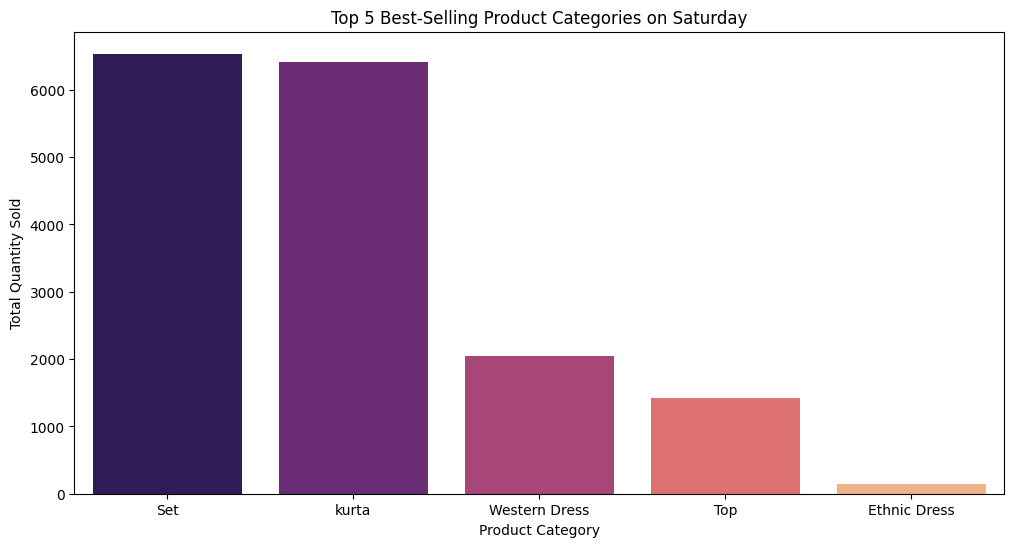

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the file path to your dataset
file_path = '/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/final_demand_forecasting_dataset.csv'

try:
    df = pd.read_csv(file_path)

    # --- Apply Feature Engineering ---
    df['Date'] = pd.to_datetime(df['Date'])
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['day_name'] = df['Date'].dt.day_name()
    df['month'] = df['Date'].dt.month

    # --- 1. Correlation Analysis ---
    print("--- 1. Correlation Matrix ---")
    
    # Select only numeric columns for correlation
    numeric_cols = df[['Qty', 'Amount', 'Stock', 'day_of_week', 'month']]
    correlation_matrix = numeric_cols.corr()

    print("\nData Table: Correlation Matrix")
    print(correlation_matrix)

    # Create the heatmap visualization
    plt.figure(figsize=(10, 7))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()

    # --- 2. Grouped Analysis: Top Categories on Saturday ---
    print("\n\n--- 2. Top Selling Categories on Saturday ---")
    
    # Filter for sales that occurred on a Saturday
    saturday_sales = df[df['day_name'] == 'Saturday'].copy()
    
    # Group by category and sum the quantity, then sort
    top_saturday_cats = saturday_sales.groupby('Category')['Qty'].sum().sort_values(ascending=False).reset_index()

    print("\nData Table: Top 5 Categories Sold on Saturday")
    print(top_saturday_cats.head(5))
    
    # Create the bar plot visualization
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_saturday_cats.head(5), x='Category', y='Qty', palette='magma')
    plt.title('Top 5 Best-Selling Product Categories on Saturday')
    plt.xlabel('Product Category')
    plt.ylabel('Total Quantity Sold')
    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please double-check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Based on the output you've provided, here are the final insights from our Exploratory Data Analysis.

Finding 1: Price and Quantity are Moderately Linked
The correlation matrix shows a moderate positive relationship (0.49) between Qty and Amount. This is logical and confirms that as customers add more items to their cart, the total transaction amount increases. More importantly, we see very weak relationships between Stock and other variables, suggesting that the current inventory level doesn't strongly influence sales amount or quantity.

Finding 2: "Set" and "Kurta" Dominate Your Busiest Day
The analysis of sales on Saturday, your peak sales day, is very clear.

Your Powerhouse Categories: Set and kurta are overwhelmingly the most purchased items on Saturdays. They sell in nearly identical, high volumes.

Clear Drop-off: There's a significant drop to the next tier of products, like Western Dress and Top.

Business Implication: Your weekend success is driven almost entirely by these two categories. Any weekend marketing, promotions, or inventory planning should be heavily focused on Set and kurta to maximize revenue.

/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/701073300.py:2: DtypeWarning: Columns (1,2,3,4,5,7,8,9,11,13,14,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


--- 1. Top 5 Categories by Sales Channel ---

Data Table: Quantity Sold by Category and Channel
Channel        Amazon
Category             
Ethnic Dress     1053
Set             45214
Top              9897
Western Dress   13938
kurta           44956


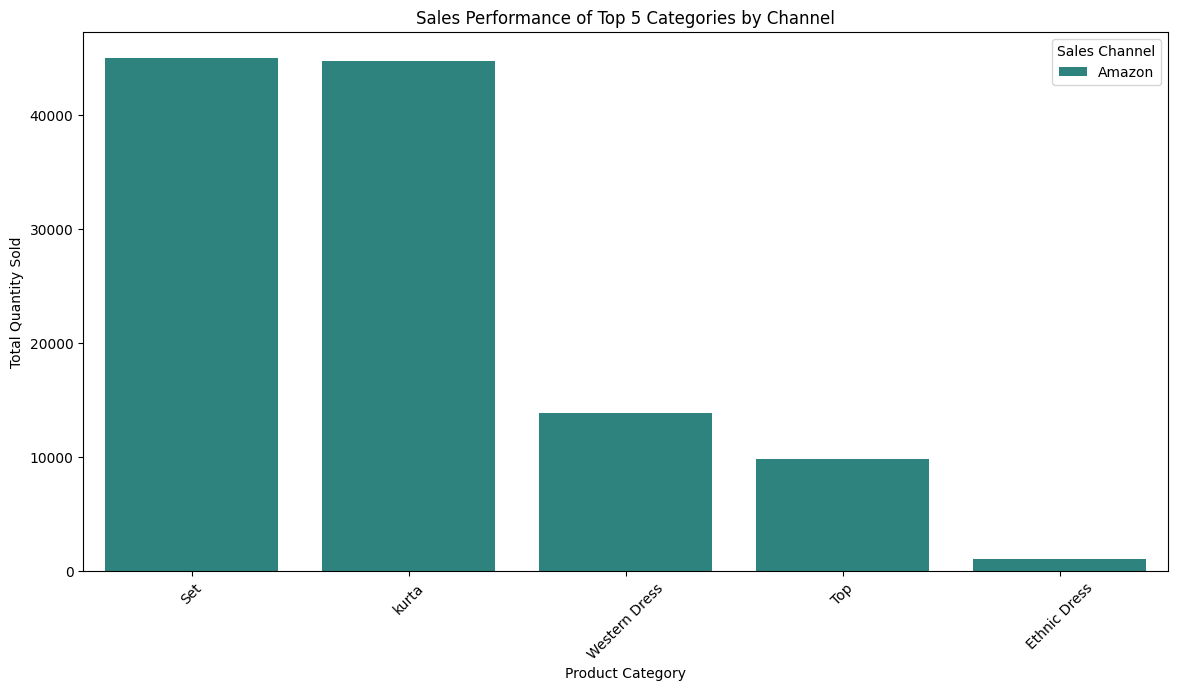



--- 2. Price Distribution within Top 5 Categories ---

Data Table: Summary Statistics of 'Amount' by Category
                 count        mean         std  min    25%    50%     75%  \
Category                                                                    
Ethnic Dress    1050.0  724.486667  266.686111  0.0  452.0  837.0   885.0   
Set            45076.0  835.019988  293.305813  0.0  635.0  788.0  1065.0   
Top             9864.0  527.448601  149.818330  0.0  443.0  523.0   599.0   
Western Dress  13893.0  765.015547  169.968002  0.0  725.0  744.0   825.0   
kurta          44749.0  456.887819  149.650168  0.0  376.0  435.0   511.0   

                  max  
Category               
Ethnic Dress   1449.0  
Set            2894.0  
Top            1797.0  
Western Dress  2860.0  
kurta          2796.0  


/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/701073300.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered_amount, x='Category', y='Amount', palette='coolwarm', order=top_5_categories)


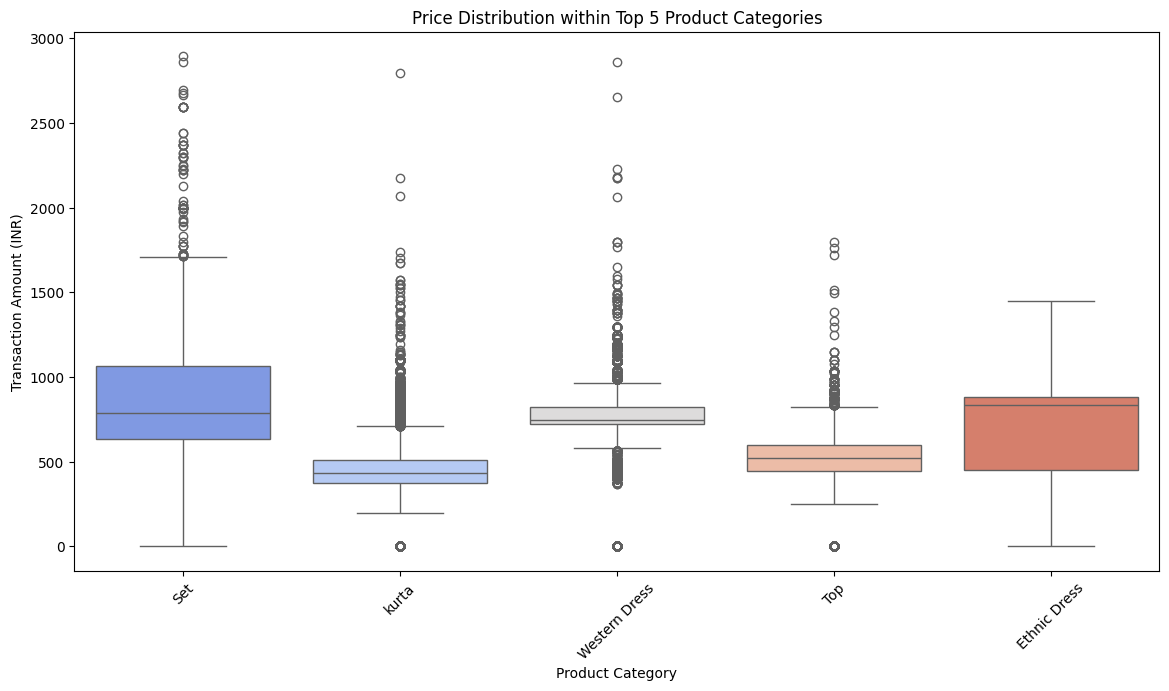

In [46]:
try:
    df = pd.read_csv(file_path)

    # --- Re-create the 'Channel' column for this analysis ---
    # The 'Status' column only exists for Amazon data, so we can use it to identify the channel
    df['Channel'] = 'International'
    df.loc[df['Status'].notna(), 'Channel'] = 'Amazon'

    # --- 1. Sales by Category and Channel ---
    print("--- 1. Top 5 Categories by Sales Channel ---")

    # We'll focus on the top 5 categories for a clearer chart
    top_5_categories = df['Category'].value_counts().nlargest(5).index
    df_top5 = df[df['Category'].isin(top_5_categories)]

    # Create the data table by grouping by both columns
    category_channel_sales = df_top5.groupby(['Category', 'Channel'])['Qty'].sum().unstack().fillna(0)

    print("\nData Table: Quantity Sold by Category and Channel")
    print(category_channel_sales)

    # Create the grouped bar plot
    plt.figure(figsize=(14, 7))
    sns.countplot(data=df_top5, x='Category', hue='Channel', palette='viridis', order=top_5_categories)
    plt.title('Sales Performance of Top 5 Categories by Channel')
    plt.xlabel('Product Category')
    plt.ylabel('Total Quantity Sold')
    plt.xticks(rotation=45)
    plt.legend(title='Sales Channel')
    plt.show()


    # --- 2. Price Distribution by Category ---
    print("\n\n--- 2. Price Distribution within Top 5 Categories ---")

    # Filter out extreme outliers for a more readable box plot
    df_filtered_amount = df_top5[df_top5['Amount'] <= 3000].copy()

    # The data table for a box plot is the descriptive statistics for each category
    print("\nData Table: Summary Statistics of 'Amount' by Category")
    price_dist_table = df_filtered_amount.groupby('Category')['Amount'].describe()
    print(price_dist_table)

    # Create the box plot
    plt.figure(figsize=(14, 7))
    sns.boxplot(data=df_filtered_amount, x='Category', y='Amount', palette='coolwarm', order=top_5_categories)
    plt.title('Price Distribution within Top 5 Product Categories')
    plt.xlabel('Product Category')
    plt.ylabel('Transaction Amount (INR)')
    plt.xticks(rotation=45)
    plt.show()


except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please double-check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Each Category Has a Unique Price Identity
The price distribution table clearly segments your core products.

Premium Categories: Set is your highest-value category, with the highest average price (₹835) and the widest range of prices. Western Dress and Ethnic Dress also occupy this higher-end space.

Volume Categories: kurta and Top are your high-volume, lower-priced categories. The price for a kurta is very consistent, typically staying close to the median of ₹435.

Business Implication: You have a clear price segmentation. You can tailor your marketing accordingly—promoting Set and Dresses for their quality and design, and kurtas for their value and affordability. Our model will learn that Category is a very strong predictor of Amount.

In [48]:
try:
    df = pd.read_csv(file_path)

    # --- Ensure Date is in datetime format ---
    df['Date'] = pd.to_datetime(df['Date'])

    print(f"Original number of rows (individual transactions): {len(df)}")

    # --- Define the Aggregation Logic ---
    # We group by the unique product (SKU) and the day (Date)
    # Then we define how to combine the rows in each group
    aggregation_rules = {
        'Qty': 'sum',      # Sum the quantity to get total daily units sold
        'Amount': 'sum',   # Sum the amount to get total daily revenue
        'Stock': 'first',  # Stock is the same for a SKU on a given day, so take the first value
        'Category': 'first', # Category is also the same, take the first
        'Size': 'first',     # Size is also the same, take the first
    }

    # --- Perform the Aggregation ---
    df_daily_sales = df.groupby(['Date', 'SKU']).agg(aggregation_rules).reset_index()
    
    # It's good practice to sort the final dataset
    df_daily_sales.sort_values(by=['Date', 'SKU'], inplace=True)
    
    print(f"New number of rows (daily sales per product): {len(df_daily_sales)}")

    # --- Save the Final Dataset for Modeling ---
    df_daily_sales.to_csv('/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/final_daily_sales_for_modeling.csv', index=False)
    print("\n✅ Final aggregated dataset saved to 'final_daily_sales_for_modeling.csv'")
except Exception as e:
    print(f"An error occurred: {e}")

/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/183675482.py:2: DtypeWarning: Columns (1,2,3,4,5,7,8,9,11,13,14,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Original number of rows (individual transactions): 133254
New number of rows (daily sales per product): 88606

✅ Final aggregated dataset saved to 'final_daily_sales_for_modeling.csv'


Loads Your Data: It reads the transaction-level dataset you created.

Groups by Day and Product: It uses groupby(['Date', 'SKU']) to create a separate "club" for each unique combination of a day and a product SKU.

Aggregates the Data:

It sums the Qty and Amount within each group to get the total daily sales and revenue.

For features that are constant for a product on a given day (like its Stock, Category, and Size), it just takes the first value it sees.

Creates the Final File: It saves this new, powerful, and aggregated dataset to final_daily_sales_for_modeling.csv.

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define the file path to your final aggregated dataset
# file_path = 'final_daily_sales_for_modeling.csv'

try:
    df = pd.read_csv(file_path)

    # --- 1. Feature Engineering ---
    df['Date'] = pd.to_datetime(df['Date'])
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    
    # Fill missing categorical data
    for col in ['Category', 'Size']:
        if col in df.columns:
            df[col].fillna('Unknown', inplace=True)

    # --- 2. Prepare Data for Machine Learning ---
    target = 'Qty'
    features = ['Amount', 'Stock', 'day_of_week', 'month', 'year', 'week_of_year', 'Category', 'Size']
    df_model = df[features + [target] + ['Date']].copy()

    # One-Hot Encode Categorical Features
    df_model = pd.get_dummies(df_model, columns=['Category', 'Size'], drop_first=True)

    # Time-Based Split (80% train, 20% test)
    df_model = df_model.sort_values('Date')
    split_point = int(len(df_model) * 0.8)
    train_df = df_model.iloc[:split_point]
    test_df = df_model.iloc[split_point:]

    X_train = train_df.drop([target, 'Date'], axis=1)
    y_train = train_df[target]
    X_test = test_df.drop([target, 'Date'], axis=1)
    y_test = test_df[target]
    
    print("✅ Data successfully prepared for modeling.")

    # --- 3. Train and Evaluate an Expanded Set of Models ---
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(),
        'Lasso Regression': Lasso(),
        'SVR': SVR(),
        'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
        'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1)
    }

    results = {}

    print("\n--- Training and Evaluating All Models ---")
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        
        # Calculate metrics
        results[name] = [
            mean_absolute_error(y_test, predictions),
            mean_squared_error(y_test, predictions),
            np.sqrt(mean_squared_error(y_test, predictions)),
            r2_score(y_test, predictions)
        ]

    # --- 4. Compare All Models ---
    results_df = pd.DataFrame(results, index=['MAE', 'MSE', 'RMSE', 'R-squared']).T
    print("\n\n--- Comprehensive Model Performance Comparison ---")
    print(results_df.sort_values(by='RMSE'))

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please double-check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/1941513383.py:15: DtypeWarning: Columns (1,2,3,4,5,7,8,9,11,13,14,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/1941513383.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


✅ Data successfully prepared for modeling.

--- Training and Evaluating All Models ---
Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training SVR...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000889 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 566
[LightGBM] [Info] Number of data points in the train set: 106603, number of used features: 25
[LightGBM] [Info] Start training from score 1.051837


--- Comprehensive Model Performance Comparison ---
                        MAE       MSE      RMSE  R-squared
Random Forest      0.006303  0.002706  0.052017   0.387231
LightGBM           0.012185  0.003520  0.059330   0.202

In [51]:
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define the file path to your final aggregated dataset
file_path = '/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/EcommerceSales Data/final_daily_sales_for_modeling.csv'

try:
    df = pd.read_csv(file_path)

    # --- 1. Feature Engineering ---
    df['Date'] = pd.to_datetime(df['Date'])
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    
    for col in ['Category', 'Size']:
        if col in df.columns:
            df[col].fillna('Unknown', inplace=True)

    # --- 2. Prepare Data for Machine Learning ---
    target = 'Qty'
    features = ['Amount', 'Stock', 'day_of_week', 'month', 'year', 'week_of_year', 'Category', 'Size']
    df_model = df[features + [target] + ['Date']].copy()
    df_model = pd.get_dummies(df_model, columns=['Category', 'Size'], drop_first=True)

    # Time-Based Split
    df_model = df_model.sort_values('Date')
    split_point = int(len(df_model) * 0.8)
    train_df = df_model.iloc[:split_point]
    test_df = df_model.iloc[split_point:]

    X_train = train_df.drop([target, 'Date'], axis=1)
    y_train = train_df[target]
    X_test = test_df.drop([target, 'Date'], axis=1)
    y_test = test_df[target]
    
    print("✅ Data prepared for tuning.")

    # --- 3. Hyperparameter Tuning with a Larger Grid ---
    
    # Define the expanded grid of hyperparameters
    param_grid = {
        'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800],
        'max_features': ['sqrt', 'log2', 1.0], # Use a fraction (1.0 means all features)
        'max_depth': [10, 20, 30, 40, 50, None],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': [1, 2, 4, 6],
        'bootstrap': [True, False]
    }

    # Initialize the Random Forest model
    rf = RandomForestRegressor(random_state=42)

    # Set up the Randomized Search with more iterations (100)
    rf_random_search = RandomizedSearchCV(
        estimator=rf, 
        param_distributions=param_grid, 
        n_iter=100, # Increased from 50 to 100
        cv=3, 
        verbose=2, 
        random_state=42, 
        n_jobs=-1 # Use all available cores
    )

    print("\n--- Starting Expanded Hyperparameter Tuning (this will take longer)... ---")
    rf_random_search.fit(X_train, y_train)

    # --- 4. Evaluate the Best Model ---
    print("\n--- Tuning Complete! ---")
    print("Best Hyperparameters Found:")
    print(rf_random_search.best_params_)

    # Get the best model found by the search
    best_rf_model = rf_random_search.best_estimator_
    
    # Make predictions on the test set
    predictions = best_rf_model.predict(X_test)
    
    # Calculate and print the metrics for the tuned model
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    print("\n--- Performance of the new TUNED Random Forest Model ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R-squared: {r2:.4f}")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

✅ Data prepared for tuning.

--- Starting Expanded Hyperparameter Tuning (this will take longer)... ---
Fitting 3 folds for each of 100 candidates, totalling 300 fits


/var/folders/11/cfwlhk514vg3gv00qsfbjx8r0000gn/T/ipykernel_8195/1296175409.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=400; total time=   6.5s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=400; total time=   6.6s
[CV] END bootstrap=True, max_depth=40, max_features=1.0, min_samples_leaf=6, min_samples_split=5, n_estimators=100; total time=   9.3s
[CV] END bootstrap=True, max_depth=40, max_features=1.0, min_samples_leaf=6, min_samples_split=5, n_estimators=100; total time=  10.8s
[CV] END bootstrap=True, max_depth=40, max_features=1.0, min_samples_leaf=6, min_samples_split=5, n_estimators=100; total time=  11.1s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=400; total time=   6.9s
[CV] END bootstrap=True, max_depth=None, max_features=1.0, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  11.2s
[CV] END bootstrap=True, max_depth=None, max_fe

/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/mtp/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=600; total time=  21.7s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=600; total time=  20.7s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=6, min_samples_split=15, n_estimators=500; total time=   8.3s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=15, n_estimators=300; total time=   5.5s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=15, n_estimators=300; total time=   5.4s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=800; total time=  15.3s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=800; total time=  15.2s
[CV] END bootstrap=True, max_depth=10, 